# Data Preprocessing
1. Handle missing values (drop/impute/flag)
2. Convert categorical features to numeric (encoding)
3. Normalize numeric features if needed
4. Create train/test split: use May 2026 data as the test set, 
and the X months immediately preceding it as the training set. X is not fixed — 
treat the training window length as a tunable choice and experiment to determine 
the optimal value of X

The following features are the ones we have decided to use in our model:
- **Location & Neighborhood**: 'Latitude', 'Longitude', 'City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor', 'HighSchoolDistrict'
- **Property Features**: "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "YearBuilt", "Stories", "ViewYN", "PoolPrivateYN", "AttachedGarageYN", "GarageSpaces", "ParkingTotal"
- **Lot & Financial Information**: ListPrice, OriginalListPrice, AssociationFee, LotSizeSquareFeet, 'LotSizeAcres', 'LotSizeArea'

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df1 = pd.read_csv('../data/CRMLSSold202411.csv')
df2 = pd.read_csv('../data/CRMLSSold202412.csv')
df3 = pd.read_csv('../data/CRMLSSold202501_filled.csv')
df4 = pd.read_csv('../data/CRMLSSold202502.csv')
df5 = pd.read_csv('../data/CRMLSSold202503.csv')
df6 = pd.read_csv('../data/CRMLSSold202504.csv')
df7 = pd.read_csv('../data/CRMLSSold202505.csv')
df8 = pd.read_csv('../data/CRMLSSold202506.csv')
df9 = pd.read_csv('../data/CRMLSSold202507.csv')
df10 = pd.read_csv('../data/CRMLSSold202508.csv')
df11 = pd.read_csv('../data/CRMLSSold202509.csv')
df12 = pd.read_csv('../data/CRMLSSold202510.csv')
df13 = pd.read_csv('../data/CRMLSSold202511.csv')
df14 = pd.read_csv('../data/CRMLSSold202512.csv')
df15 = pd.read_csv('../data/CRMLSSold202601.csv')
df16 = pd.read_csv('../data/CRMLSSold202602.csv')
df17 = pd.read_csv('../data/CRMLSSold202603.csv')
df18 = pd.read_csv('../data/CRMLSSold202604.csv')
df19 = pd.read_csv('../data/CRMLSSold202605.csv')

for df in [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12, df13]:
    df['train_val_test'] = 'train'
for df in [df14, df15, df16]:
    df['train_val_test'] = 'validation'
for df in [df17, df18, df19]:
    df['train_val_test'] = 'test'

df = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12, df13, df14, df15, df16,
                df17, df18, df19], axis=0, ignore_index=True)
df = df.drop(['ListPrice', 'OriginalListPrice'], axis=1) # note: drop ListPrice and OriginalListPrice?

# Restricting analysis according to Project Document
df = df[df['PropertyType'] == 'Residential']
df = df[df['PropertySubType'] == 'SingleFamilyResidence']

/var/folders/3l/3v_d6vqj7892stpd98hwf1ym0000gn/T/ipykernel_5086/1104529825.py:8: DtypeWarning: Columns (0: WaterfrontYN) have mixed types. Specify dtype option on import or set low_memory=False.
  df8 = pd.read_csv('../data/CRMLSSold202506.csv')
/var/folders/3l/3v_d6vqj7892stpd98hwf1ym0000gn/T/ipykernel_5086/1104529825.py:15: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df15 = pd.read_csv('../data/CRMLSSold202601.csv')


In [6]:
features = ['Latitude', 'Longitude', 'City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor', 'HighSchoolDistrict',
            "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "YearBuilt", "Stories", "ViewYN", "PoolPrivateYN", "AttachedGarageYN",
            "GarageSpaces", "ParkingTotal", 'AssociationFee', 'LotSizeSquareFeet', 'ClosePrice', 'train_val_test']
# removed LotSizeArea and LotSizeAcres for redundancy with LotSizeSquareFeet

df = df[features]
df = df.reset_index().drop('index', axis=1)
df.head()

,Latitude,Longitude,City,PostalCode,CountyOrParish,MLSAreaMajor,HighSchoolDistrict,LivingArea,BedroomsTotal,BathroomsTotalInteger,...,Stories,ViewYN,PoolPrivateYN,AttachedGarageYN,GarageSpaces,ParkingTotal,AssociationFee,LotSizeSquareFeet,ClosePrice,train_val_test
0,34.347790,-117.608845,Wrightwood,92397,San Bernardino,WRWD - Wrightwood,Snowline Joint Unified,1920.0,3.0,2.0,...,2.0,True,False,True,2.0,2.0,0.0,10530.0,655000.0,train
1,37.275545,-121.926226,San Jose,95124,Santa Clara,699 - Not Defined,Other,1937.0,5.0,3.0,...,NaN,False,NaN,True,2.0,2.0,NaN,5978.0,2450000.0,train
2,38.576697,-122.582782,Calistoga,94515,Napa,699 - Not Defined,Calistoga Joint Unified,4520.0,7.0,9.0,...,NaN,False,NaN,False,0.0,0.0,NaN,19197.0,9600000.0,train
3,35.650349,-120.674937,Paso Robles,93446,San Luis Obispo,PRNE - PR North 46-East 101,Paso Robles Joint Unified,2372.0,3.0,2.0,...,1.0,False,False,True,3.0,3.0,0.0,9805.0,838000.0,train
4,34.192418,-118.309955,Burbank,91501,Los Angeles,610 - Burbank,Burbank Unified,1053.0,2.0,1.0,...,1.0,True,False,False,2.0,2.0,0.0,7937.0,890000.0,train


### 1. Handle missing values

In [7]:
# Percentage of values missing for each feature
values_missing = df.isnull().sum() / df.shape[0] * 100
values_missing.sort_values()

CountyOrParish            0.000000
BedroomsTotal             0.000000
train_val_test            0.000000
ClosePrice                0.000493
PostalCode                0.000986
ParkingTotal              0.000986
Latitude                  0.008383
Longitude                 0.008383
BathroomsTotalInteger     0.011341
LivingArea                0.054241
City                      0.057200
YearBuilt                 0.070514
LotSizeSquareFeet         1.738676
GarageSpaces              3.876271
PoolPrivateYN             8.317143
ViewYN                    8.962613
Stories                  11.242714
AttachedGarageYN         11.915798
MLSAreaMajor             14.381799
HighSchoolDistrict       26.649671
AssociationFee           29.385891
dtype: float64

In [8]:
df.describe()

,Latitude,Longitude,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,Stories,GarageSpaces,ParkingTotal,AssociationFee,LotSizeSquareFeet,ClosePrice
count,202781.000000,202781.000000,202688.000000,202798.000000,202775.000000,202655.000000,179998.000000,194937.000000,202796.000000,143204.000000,1.992720e+05,2.027970e+05
mean,34.741389,-118.611786,2043.121987,3.487741,2.629279,1975.770270,1.351559,1.999682,3.049823,105.103532,3.110036e+05,1.324878e+06
std,1.787248,3.222625,1041.530426,0.967912,1.183898,27.616662,0.477459,3.120769,43.587616,334.776316,1.615385e+07,7.148089e+06
min,-117.472493,-124.193201,0.000000,0.000000,0.000000,1776.000000,1.000000,0.000000,-143.000000,0.000000,0.000000e+00,0.000000e+00
25%,33.762632,-119.176661,1384.000000,3.000000,2.000000,1956.000000,1.000000,2.000000,2.000000,0.000000,5.663000e+03,6.250000e+05
50%,34.083871,-118.031237,1812.000000,3.000000,2.000000,1976.000000,1.000000,2.000000,2.000000,0.000000,7.264000e+03,8.900000e+05
75%,34.869285,-117.260501,2432.000000,4.000000,3.000000,1998.000000,2.000000,2.000000,3.000000,130.000000,1.044025e+04,1.425000e+06
max,43.784440,329.000000,56500.000000,45.000000,153.000000,2026.000000,2.000000,600.000000,15720.000000,20712.000000,2.087221e+09,9.895000e+08


Let's process **Latitude and Longitude.**

Manually input the coordinates of the cities for the null/(0, 0) Latitude and Longitude values.

In [9]:
city_coordinates = {
    'Carmel': (36.5552, -121.9233),
    'Marina': (36.6777, -121.8021),
    'Hollister': (36.8525, -121.4016),
    'Manteca': (37.7974, -121.2160),
    'Los Gatos': (37.2358, -121.9624),
    'Salinas': (36.6777, -121.6555),
    'Oakley': (37.9973, -121.7130),
    'Palmdale': (34.5794, -118.1165),
    'Napa': (38.2975, -122.2869),
    'Lancaster': (34.6868, -118.1542),
    'Fresno': (36.7378, -119.7871),
    'La Jolla': (32.8427, -117.2578),
    'Encinitas': (33.0370, -117.2920),
    'San Ramon': (37.7808, -121.9968),
    'Gilroy': (37.0058, -121.5683),
    'Compton': (33.8958, -118.2201)
}

for city, (lat, lon) in city_coordinates.items():
    bm = (df['City'] == city) & (df['Latitude'].isnull() | (df['Latitude'] == 0) & (df['Longitude'] == 0))
    df.loc[bm, 'Latitude'] = lat
    df.loc[bm, 'Longitude'] = lon
    

Let us investigate properties that fall outside of California's boundary.

In [10]:
# change lon sign error for rows
df.loc[df['Longitude'] > 0, 'Longitude'] = -df.loc[df['Longitude'] > 0, 'Longitude']

In [11]:
# drop rows outside of California
df = df[((df['Latitude'] > 32) & (df['Latitude'] < 42.5))
         & ((df['Longitude'] > -124.5) & (df['Longitude'] < -114))]

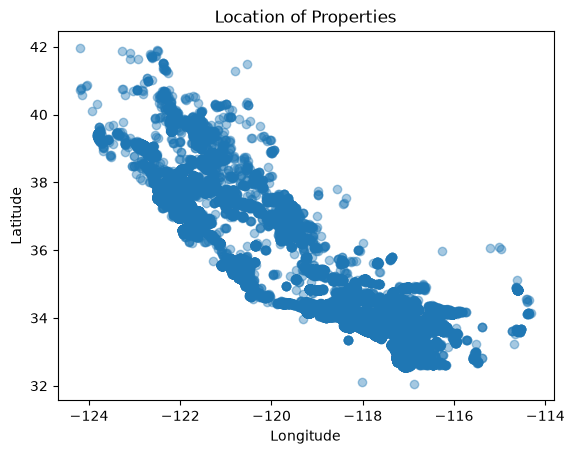

In [12]:
plt.title('Location of Properties')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.4);

Let's process 'City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor' (marketing area name), 'HighSchoolDistrict'.

Impute City values based on PostalCode.

In [13]:
postal_code_cities = {
    '90291': 'Venice',
    '91326': 'Porter Ranch',
    '91352-4319': 'Sun Valley',
    '92028': 'Fallbrook',
    '92037': 'La Jolla',
    '92116': 'San Diego',
    '92123': 'San Diego',
    '92277': 'Twentynine Palms',
    '92314': 'Big Bear City',
    '92399': 'Yucaipa',
    '92440': 'San Bernardino',
    '92567': 'San Jacinto',
    '93202': 'Armona',
    '93261': 'Richgrove',
    '93272': 'Tipton',
    '93506': 'Mojave',
    '93668': 'Tranquillity',
    '93908': 'Salinas',
    '93933': 'Marina',
    '94062': 'Redwood City',
    '94112': 'San Francisco',
    '94571-5507': 'Suisun City',
    '94574': 'St. Helena',
    '94578-1428': 'San Leandro',
    '94598-2356': 'Walnut Creek',
    '94940': 'Fairfax',
    '95004': 'Aromas',
    '95076': 'Watsonville',
    '95132-3226': 'San Jose',
    '95346': 'Groveland',
    '95560': 'Redway',
    '95670': 'Rancho Cordova',
    '94124-2754': 'San Francisco',
    '93256': 'Pixley',
    '94065': 'Redwood City',
    '95961': 'Olivehurst',
    '92117': 'San Diego',
    '92240': 'Desert Hot Springs',
    '95002': 'Alviso',
    '95614': 'Cool',
    '95672': 'Rescue',
    '94933': 'Forest Knolls',
    '92679': 'Trabuco Canyon',
    '95628': 'Fair Oaks',
    '95385': 'Vernalis',
    '94550': 'Livermore',
    '95567': 'Smith River',
    '94920': 'Tiburon',
    '93608': 'Cantua Creek',
    '94516': 'Canyon',
    '93267': 'Strathmore',
    '92308': 'Apple Valley',
    '95364': 'Pinecrest',
    '94303': 'Palo Alto',
    '94028': 'Portola Valley',
    '93266': 'Stratford'
}

for postal_code, city in postal_code_cities.items():
    bm = (df['PostalCode'] == postal_code) & (df['City'].isnull())
    df.loc[bm, 'City'] = city

Drop PostalCode null rows.

In [14]:
df = df[~df['PostalCode'].isnull()]

CountyOrParish is not missing any values.

Replace NaN MLSAreaMajor values with '699 - Not Defined'.

In [15]:
df['MLSAreaMajor'] = df['MLSAreaMajor'].fillna('699 - Not Defined')

There are a high amount of HighSchoolDistrict values missing. Fill in NaN values with 'Missing'.

In [16]:
df['HighSchoolDistrict'] = df['HighSchoolDistrict'].fillna('Missing')

In [17]:
# Fill boolean values with 'Unknown'
df['ViewYN'] = df['ViewYN'].fillna('Unknown')
df['PoolPrivateYN'] = df['PoolPrivateYN'].fillna('Unknown')
df['AttachedGarageYN'] = df['AttachedGarageYN'].fillna('Unknown')

Drop the rows with a ClosePrice of 100 or less.

In [18]:
df = df[df['ClosePrice'] > 100]

Filter out outliers only for the training set.

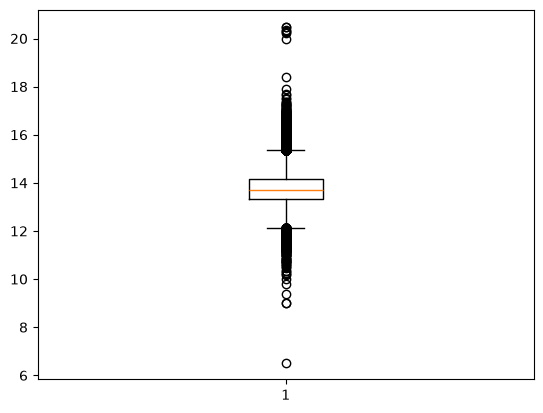

In [19]:
train_data = df[df['train_val_test'] == 'train']
Q1 = np.log1p(train_data['ClosePrice']).quantile(0.25)
Q3 = np.log1p(train_data['ClosePrice']).quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

is_outlier = (np.log1p(df['ClosePrice']) <= lower_bound) | (np.log1p(df['ClosePrice']) >= upper_bound)
is_train = df['train_val_test'] == 'train'

df = df[~(is_outlier & is_train)]
plt.boxplot(np.log1p(df['ClosePrice']));

### 2. Train/Test Split + Imputation

In [20]:
train = df[df['train_val_test'] == 'train']
val = df[df['train_val_test'] == 'validation']
test = df[df['train_val_test'] == 'test']

X_train = train.drop(['ClosePrice', 'train_val_test'], axis=1)
X_val = val.drop(['ClosePrice', 'train_val_test'], axis=1)
X_test = test.drop(['ClosePrice', 'train_val_test'], axis=1)

Y_train = train[['ClosePrice']]
Y_val = val[['ClosePrice']]
Y_test = test[['ClosePrice']]

Let us use group median imputation for "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "YearBuilt", "Stories", "GarageSpaces", "ParkingTotal", "LotSizeSquareFeet". We do this separately for the train, val, and test sets.

In [21]:
for X_df in [X_train, X_val, X_test]:
    # put negative ParkingTotal values as NaN
    X_df['ParkingTotal'] = X_df['ParkingTotal'].where(X_df['ParkingTotal'] >= 0, np.nan)
    
    for med_imputation in ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "YearBuilt", "Stories", "GarageSpaces", "ParkingTotal", "LotSizeSquareFeet", "AssociationFee"]:
        # Impute missing numerical values with median value
        X_df[med_imputation] = X_df[med_imputation].fillna(X_df[med_imputation].median())

        # # Impute missing numerical values with median value of the nearby properties (same city)
        # X_df[med_imputation] = X_df.groupby('City')[med_imputation].transform(lambda sf : sf.fillna(sf.median()))
        # if X_df[med_imputation].hasnans:
        #     X_df[med_imputation] = X_df.groupby('CountyOrParish')[med_imputation].transform(lambda sf : sf.fillna(sf.median()))
        #     X_df[med_imputation] = X_df[med_imputation].fillna(X_df[med_imputation].median())

for Y_df in [Y_train, Y_val, Y_test]:
    Y_df['ClosePrice'] = Y_df['ClosePrice'].fillna(Y_df['ClosePrice'].median())

In [22]:
values_missing = X_val.isnull().sum() / X_val.shape[0] * 100
values_missing.sort_values()

Latitude                 0.0
Longitude                0.0
City                     0.0
PostalCode               0.0
CountyOrParish           0.0
MLSAreaMajor             0.0
HighSchoolDistrict       0.0
LivingArea               0.0
BedroomsTotal            0.0
BathroomsTotalInteger    0.0
YearBuilt                0.0
Stories                  0.0
ViewYN                   0.0
PoolPrivateYN            0.0
AttachedGarageYN         0.0
GarageSpaces             0.0
ParkingTotal             0.0
AssociationFee           0.0
LotSizeSquareFeet        0.0
dtype: float64

### 3. Normalization and Log Transformation

Based on scatter plots, we should log transform not only ClosePrice, but LivingArea, GarageSpaces, ParkingTotal, LotSizeSquareFeet, and AssociationFee.

In [23]:
for X_log in [X_train, X_val, X_test]:
    X_log['LivingArea'] = np.log1p(X_log['LivingArea'])
    X_log['GarageSpaces'] = np.log1p(X_log['GarageSpaces'])
    X_log['ParkingTotal'] = np.log1p(X_log['ParkingTotal'])
    X_log['LotSizeSquareFeet'] = np.log1p(X_log['LotSizeSquareFeet'])
    X_log.drop(['LivingArea', 'GarageSpaces', 'ParkingTotal', 'LotSizeSquareFeet', 'AssociationFee'], axis=1)

In [24]:
# from sklearn.preprocessing import MinMaxScaler

# scaled_cols = ['Latitude', 'Longitude', 'LivingArea', 'BedroomsTotal', 'AssociationFee',
#                  'BathroomsTotalInteger', 'YearBuilt', 'Stories', 'GarageSpaces', 'ParkingTotal', 'LotSizeSquareFeet']

# scaler = MinMaxScaler()
# X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
# X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

### 3. Encoding

Categorical features: "City", "PostalCode", "CountyOrParish", "MLSAreaMajor", "HighSchoolDistrict", "ViewYN", "PoolPrivateYN", "AttachedGarageYN"
- Nominal: City, PostalCode, CountyOrParish, MLSAreaMajor, HighSchoolDistrict
- Ordinal: N/A
- Binary (w/ 'Unknown'): ViewYN, PoolPrivateYN, AttachedGarageYN
- High-Cardinality: City, PostalCode, MLSAreaMajor, HighSchoolDistrict

Let us One-Hot Encode CountyOrParish, ViewYN, PoolPrivateYN, AttachedGarageYN. Let us use Target Encoding for the high cardinality features, City, PostalCode, MLSAreaMajor, and HighSchoolDistrict.

In [25]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder

# --- Encoding ---

# convert boolean columns to string values in order for OneHotEncoder and TargetEncoder to work
for bin_col in ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'PostalCode']:
    X_train[bin_col] = X_train[bin_col].astype(str)

# One hot encode X dfs - (EDIT LOG COLUMNS IF GOING TO LOG TRANSFORM)
non_ohe_cols = ['Latitude', 'Longitude', 'City', 'PostalCode', 'MLSAreaMajor', 'HighSchoolDistrict', 'LivingArea', 'BedroomsTotal',
                 'BathroomsTotalInteger', 'YearBuilt', 'Stories', 'GarageSpaces', 'ParkingTotal', 'AssociationFee', 'LotSizeSquareFeet']
ohe_cols = ['CountyOrParish', 'ViewYN', 'PoolPrivateYN', 'AttachedGarageYN']

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False) # drop='first' avoids multicolinearity --> we can use an intercept in our model
ohe.fit(X_train[ohe_cols]) # fit only on training data

X_train_ohe_array = ohe.transform(X_train[ohe_cols])
X_val_ohe_array = ohe.transform(X_val[ohe_cols])
X_test_ohe_array = ohe.transform(X_test[ohe_cols])
X_train_ohe = pd.DataFrame(X_train_ohe_array, index=X_train.index, columns=ohe.get_feature_names_out(ohe_cols))
X_val_ohe = pd.DataFrame(X_val_ohe_array, index=X_val.index, columns=ohe.get_feature_names_out(ohe_cols))
X_test_ohe = pd.DataFrame(X_test_ohe_array, index=X_test.index, columns=ohe.get_feature_names_out(ohe_cols))

X_train = pd.concat([X_train[non_ohe_cols], X_train_ohe], axis=1)
X_test = pd.concat([X_test[non_ohe_cols], X_test_ohe], axis=1)
X_val = pd.concat([X_val[non_ohe_cols], X_val_ohe], axis=1)

# Target Encode X dfs
te_cols = ['City', 'PostalCode', 'MLSAreaMajor', 'HighSchoolDistrict']

te = TargetEncoder(target_type='continuous')
te.fit(X_train[te_cols], Y_train)

X_train_te_array = te.transform(X_train[te_cols])
X_val_te_array = te.transform(X_val[te_cols])
X_test_te_array = te.transform(X_test[te_cols])
X_train_te = pd.DataFrame(X_train_te_array, index=X_train.index, columns=te_cols)
X_val_te = pd.DataFrame(X_val_te_array, index=X_val.index, columns=te_cols)
X_test_te = pd.DataFrame(X_test_te_array, index=X_test.index, columns=te_cols)

X_train[te_cols] = X_train_te
X_val[te_cols] = X_val_te
X_test[te_cols] = X_test_te

# Frequency encoding X dfs
# for feature in fe_cols:
#     fre_train = X_train[feature].value_counts(normalize=True).to_dict()

#     X_train[feature] = X_train[feature].map(fre_train)
#     X_val[feature] = X_val[feature].map(fre_train)
#     X_test[feature] = X_test[feature].map(fre_train)

#     X_train[feature] = X_train[feature].fillna(0)
#     X_val[feature] = X_val[feature].fillna(0)
#     X_test[feature] = X_test[feature].fillna(0)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Now let us use these sets with a Linear Regression model.

Training score:  0.8102311912023128
Validation score:  0.7874895057686073


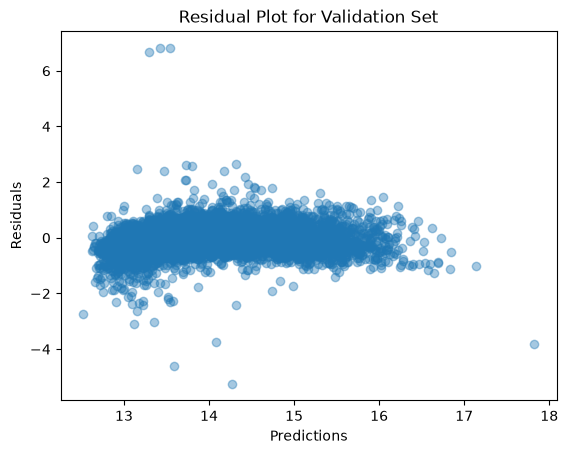

In [26]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression() # fit_intercept=True
# log transform ClosePrice
lr.fit(X_train, np.log1p(Y_train))

print('Training score: ', lr.score(X_train, np.log1p(Y_train)))
print('Validation score: ', lr.score(X_val, np.log1p(Y_val)))

predictions = lr.predict(X_val)
residuals = np.log1p(Y_val) - predictions

plt.scatter(predictions, residuals, alpha=0.4)
plt.title('Residual Plot for Validation Set')
plt.xlabel('Predictions')
plt.ylabel('Residuals');

In [ ]:
# USING THIS IN 03_baseline_model.ipynb
X_train.to_csv("X_train.csv", index=False)
X_val.to_csv("X_val.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

np.save("Y_train.npy", Y_train)
np.save("Y_val.npy", Y_val)
np.save("Y_test.npy", Y_test)